This script should be run in a folder containing the file 'data.dat'

This file should be a two column, tab delimited file without any headers. When lxcat files are exported from the lxcat website in .txt form, the individual cross sections should be copy and pasted from the .txt file into the data.dat file without any headers. This should leave the data.dat file in the correct format for this script.

In [1]:
import lmfit
import matplotlib.pyplot as plt
import numpy as np
from inspect import getsource
from pygments import highlight
from pygments.lexers import PythonLexer
from pygments.formatters import HtmlFormatter
from IPython.display import HTML
from xs2arr import Model
from xs2arr.cross_section import interpolate_xs
from xs2arr.rate import compute_rate_simpson
from xs2arr.utils import arrhenius_log, m_e, q

# Define some function needed for output later
formatter = HtmlFormatter(noclasses=True, style="friendly")
css = f"<style>{formatter.get_style_defs('.highlight')}</style>"
print_html = lambda code: HTML(css + highlight(code, PythonLexer(), formatter))

file_path = '../tests/example_lxcat.txt'

# Create the model with a Maxwellian EEDF and defined energy grid
eedf_grid = np.linspace(start=0.0, stop=100.0, num=10000, dtype=float)
model = Model(file_path, eedf_type="maxwellian", eedf_grid=eedf_grid)

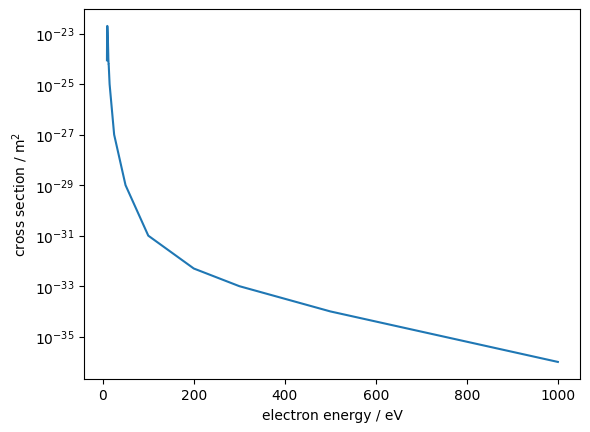

In [2]:
cross_section = model.cross_section_set.cross_sections[0]

# Plot imported cross section data - cross check that it is consistent with that from LXCat

plt.semilogy(cross_section.data["energy"], cross_section.data["cross section"])

plt.xlabel("electron energy / eV")
plt.ylabel("cross section / m$^2$")

plt.show()

In [3]:
# Let's look at the EEDF we asked for (Maxwellian)
# EEDF is according to section 4.2 in J. R. Hamilton et al 2018 Plasma Sources Sci. Technol. 27 095008
# This is in turn from Gudmundsson J 2001 Plasma Sources Sci. Technol. 10 76

EEDF = model.eedf_cls

# Here is the source code defining the probabiliy density function
code = getsource(EEDF.pdf)
print_html(code)

Mean energy = 4.5 eV


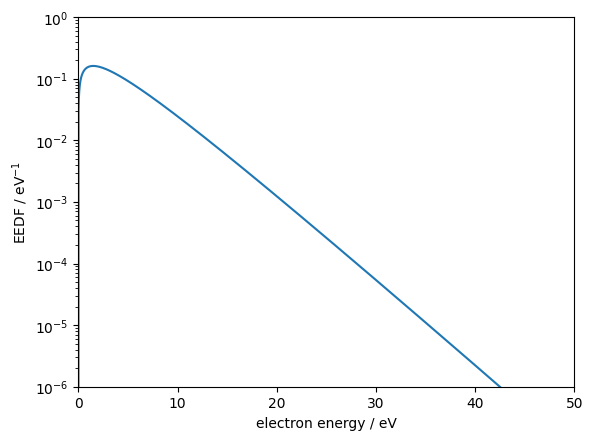

In [4]:
# When we instantiate an object of the EEDF class with a given temperature, this will define the mean energy
eedf = EEDF(Te=3.0)
print(f"Mean energy = {eedf.mean_E} eV")

# Here is the PDF for the given array of energies we defined earlier
pdf = eedf.pdf(eedf_grid)

plt.semilogy(eedf_grid, pdf)

plt.xlabel("electron energy / eV")
plt.ylabel("EEDF / eV$^{-1}$")

plt.xlim(0, 50)
plt.ylim(1e-6, 1)

plt.show()

In [5]:
# Here, the cross section data is being interpolated in preparation for the calcualtion of rate coefficients.
# This is needed to put the cross section data on the same energy grid as the EEDFs.
# Because the cross sections have an exponential dependence on energy at low energies, and this is important for
# the rate coefficients at low energies, the data is first transformed into log10 form.
# After that, the interpolation takes place in log10space. This ensures that cross sections with low values around
# the energy threshold are not missed by the interpolation. After interpolation, the log10 conversion is reversed.

EEDF = model.eedf_cls

# Here is the source code for the interpolation process
code = getsource(interpolate_xs)
print_html(code)


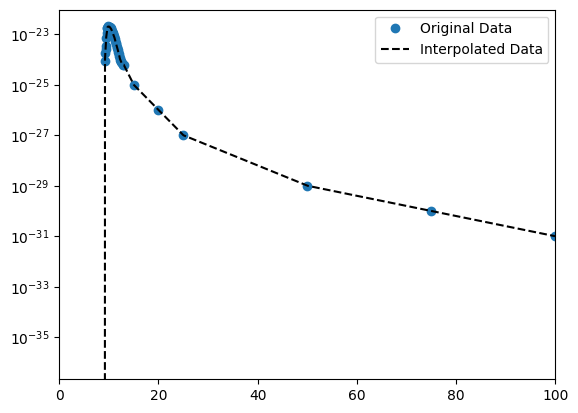

In [6]:
# Let's interpolate the example cross section we chose before onto the energy grid.
xs_interp = interpolate_xs(eedf_grid, cross_section.data["energy"], cross_section.data["cross section"])

plt.semilogy(cross_section.data["energy"], cross_section.data["cross section"], "o", label="Original Data")
plt.semilogy(eedf_grid, xs_interp, "k--", label="Interpolated Data")
plt.legend()

plt.xlim(0,100)

plt.show()

In [7]:
# The rate constants, k, are calculated as a function of temperature
# This is done by applying the numerical Simpson's integration onto equation (2)
# in J. R. Hamilton et al 2018 Plasma Sources Sci. Technol. 27 095008

# Here is the source code for the integration process
code = getsource(compute_rate_simpson)
print_html(code)

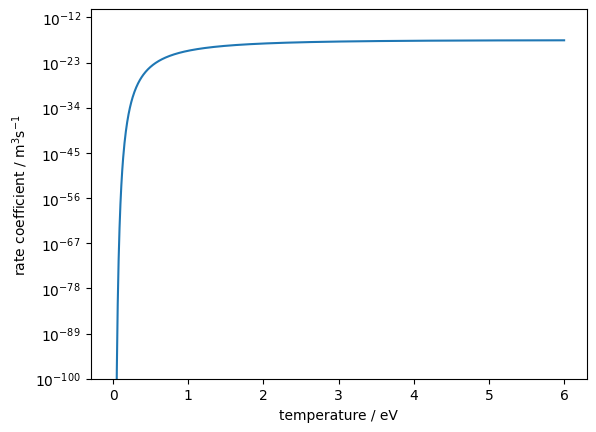

In [8]:
# Let's do the integrals with a temperature grid
T_grid = np.linspace(start=0.001, stop=6.0, num=1000, dtype=float)

# The EEDF is instantiated for each temperature, and its PDF calculated
# It is then fed into the integration function along with the EEDF grid and interpolated cross section
rates = np.asarray([compute_rate_simpson(eedf_grid, xs_interp, EEDF(T).pdf(eedf_grid)) for T in T_grid])

# Convert rates to SI units
rates *= np.sqrt(2.0 * q / m_e)  # q is the elementary charge. m_e is the electron mass

# Let's plot the rate coefficients to see if they appear reasonable
plt.semilogy(T_grid, rates)

plt.ylim(1e-100, 1e-10)

plt.xlabel("temperature / eV")
plt.ylabel("rate coefficient / m$^3$s$^{-1}$")

plt.show()

In [9]:
# Here, we fit the rate coefficients as a function of tempearture

# We use the logarithm of the Arrhenius equation
# This is a general, and physically sensible function for rate coefficients
# One aspect to pay attention to is that the magnitude of the "c" coefficient
# should be similar to the energy threshold for the process
code = getsource(arrhenius_log)
print_html(code)

In [10]:
# Now, we define the fit model used in lmfit to be the Arrenhius expression defined above
regressor = lmfit.Model(arrhenius_log, independent_vars=["T"])

# And make initial guesses for coefficients. These should be suitable for most processes with a relatively high
# energy threshold (e.g. 5 eV and above), but may need to be varied if a suitable fit is not obtained
params = lmfit.create_params(log10_a={"value": -14.0}, b=0.1, c={"value": -10.0, "max": 0.0})

# We remove almost 0 values from the data to avoid problems when fitting
mask = rates > 0.0
T_grid = T_grid[mask]
rates = rates[mask]

# And apply log10 to the rates
rates = np.log10(rates)

# Carry out the fit
results = regressor.fit(rates, params, T=T_grid)

print(results.fit_report())

[[Model]]
    Model(arrhenius_log)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 13
    # data points      = 997
    # variables        = 3
    chi-square         = 9.62918361
    reduced chi-square = 0.00968731
    Akaike info crit   = -4620.03247
    Bayesian info crit = -4605.31821
    R-squared          = 0.99993426
[[Variables]]
    log10_a: -16.1852896 +/- 0.00556420 (0.03%) (init = -14)
    b:       -0.81852257 +/- 0.01019485 (1.25%) (init = 0.1)
    c:       -9.31708049 +/- 0.00317996 (0.03%) (init = -10)
[[Correlations]] (unreported correlations are < 0.100)
    C(log10_a, b) = -0.8082
    C(log10_a, c) = -0.6781
    C(b, c)       = +0.6728


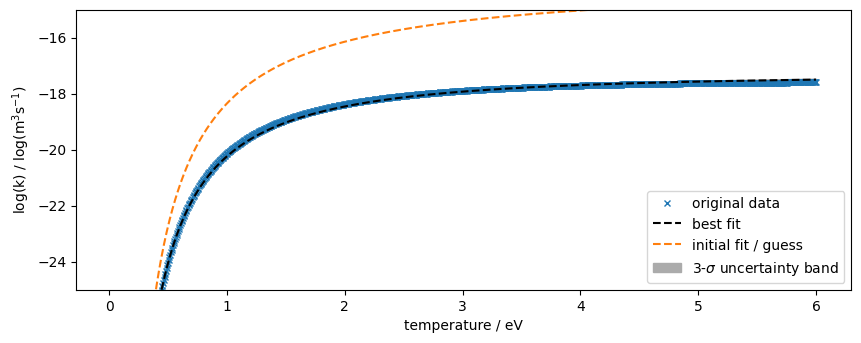

In [11]:
# The following provides a measure of uncertainty (3 sigma = 3 standard deviations of the mean) in the fit
dely = results.eval_uncertainty(sigma=3)

# Define y_fit as the best fit calculated from results, init_fit is initial guesses
y_fit = results.best_fit
init_fit = results.init_fit

# The boundaries of the measure of uncertainty
up = y_fit + dely
dn = y_fit - dely

# Plot results and examine various aspects to check that they make sense and are useful
plt.figure(figsize=(10, 8))
plt.subplot(2, 1, 1)

plt.plot(T_grid, rates, "x", label="original data", ms=5) # plot original data
plt.plot(T_grid, y_fit, "k--", label="best fit") # plot best fit
plt.plot(T_grid, init_fit, '--', label='initial fit / guess') # plot initial fit from initial guess

# Plot the uncertainy results as a grey shaded area
plt.fill_between(T_grid, dn, up, color="#ABABAB",
                 label=r'3-$\sigma$ uncertainty band')

plt.ylim(-25, -15)

plt.xlabel("temperature / eV")
plt.ylabel("log(k) / log(m$^3$s$^{-1}$)")

plt.legend()

plt.show()

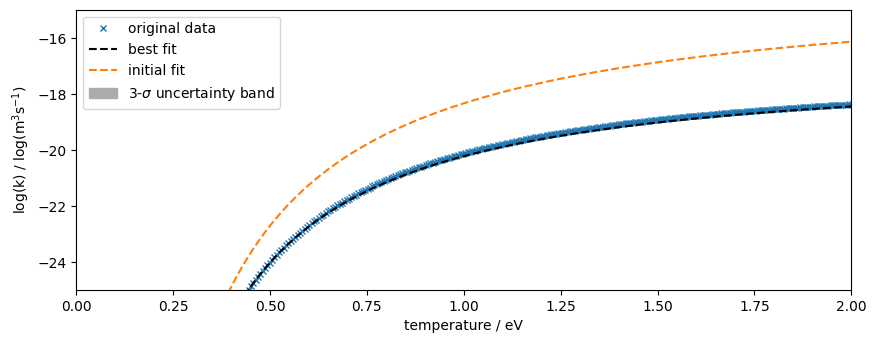

In [12]:
# Below is the same as above, but with a more limited x axis range that focuses on the threshold region as this is an area
# that can be difficult to fit properly

plt.figure(figsize=(10, 8))
plt.subplot(2, 1, 2)

plt.plot(T_grid, rates, "x", label="original data", ms=5)
plt.plot(T_grid, y_fit, "k--", label="best fit")
plt.plot(T_grid, init_fit, '--', label='initial fit')

plt.fill_between(T_grid, dn, up, color="#ABABAB", label=r'3-$\sigma$ uncertainty band')

plt.xlim(0,2)
plt.ylim(-25, -15)

plt.xlabel("temperature / eV")
plt.ylabel("log(k) / log(m$^3$s$^{-1}$)")

plt.legend()

plt.show()

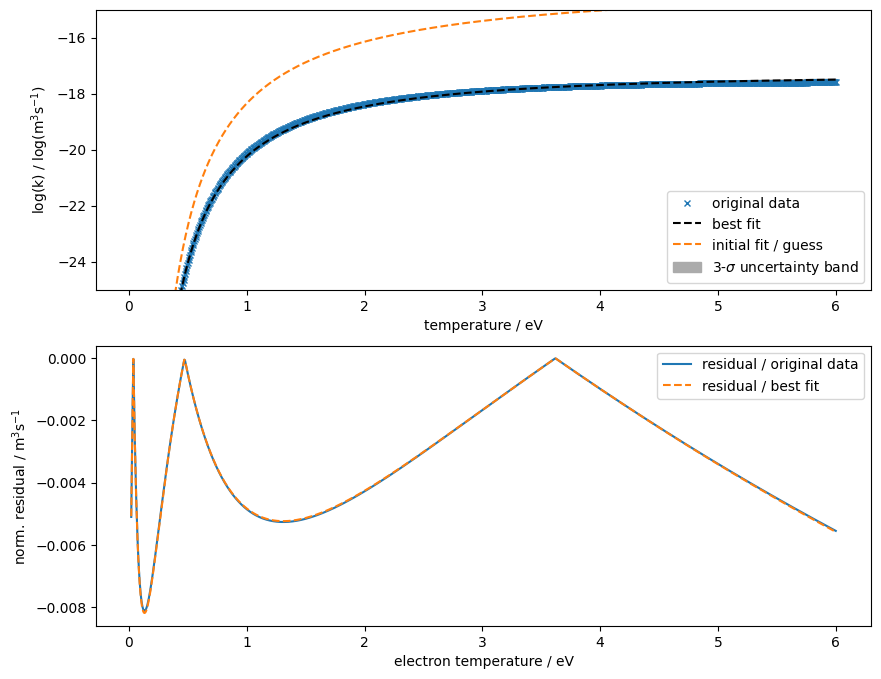

In [14]:
# In the plots above we can see that the quality of the fit varies a little with temperature
# This can be assessed more quantitatively by looking at the "residual" of the fit
# This quantifies the difference between the fit and the data which is being fitted

plt.figure(figsize=(10, 8))
plt.subplot(2, 1, 1)

plt.plot(T_grid, rates, "x", label="original data", ms=5) # plot original data
plt.plot(T_grid, y_fit, "k--", label="best fit") # plot best fit
plt.plot(T_grid, init_fit, '--', label='initial fit / guess') # plot initial fit from initial guess

plt.fill_between(T_grid, dn, up, color="#ABABAB", label=r'3-$\sigma$ uncertainty band')

plt.xlabel("temperature / eV")
plt.ylabel("log(k) / log(m$^3$s$^{-1}$)")
plt.legend()
plt.ylim(-25,-15)


# The figure below plots the residual of the fit divided by the value of the fit itself, as well as the residual
# divided by the value of the data
# Both give a normalised view of the residual i.e. how big is it relevant to the data or fit itself
# this can be more useful than the residual itself, as the relative importance is generally more useful than the
# absolute residual when the value of the data itself varies by several orders of magnitude
# A "good" fit is indicated when both of these quantities are much less than 1
# for this data, this generally occurs at Te above than around 2 eV, as the fit gets worse a lower values
# so quantitatively, we can say the fit is proper above 2 eV
# However, since the values themselves are very low below 2 eV, even relatively large differences should not
# affect the final plasma model much, especially since Te is generally larger than 2 eV in our plasma systems
# So, we can probably use the fit over the whole range, but we should keep in mind that we have larger uncertainties at low Te 
plt.subplot(2, 1, 2)
plt.plot(T_grid, np.absolute(results.residual) / rates, label="residual / original data")
plt.plot(T_grid, np.absolute(results.residual) / y_fit, '--', label="residual / best fit")

#plt.ylim(-6,2)
plt.xlabel("electron temperature / eV")
plt.ylabel("norm. residual / m$^3$s$^{-1}$")

plt.legend()

plt.show()